### Import libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')


### Add CSV to test

In [37]:
Salary_CSV = pd.read_csv('Salary_Data.csv')
Salary_CSV.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Creating and Training Linear Regrassion Model

In [38]:
model = LinearRegression()
model.fit(Salary_CSV[['YearsExperience']], Salary_CSV['Salary'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9449.96]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.579e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


### Predicting Y Values - here it is Salary

In [39]:
Y_pred = model.predict(Salary_CSV[['YearsExperience']])

### Visualizing the Plot

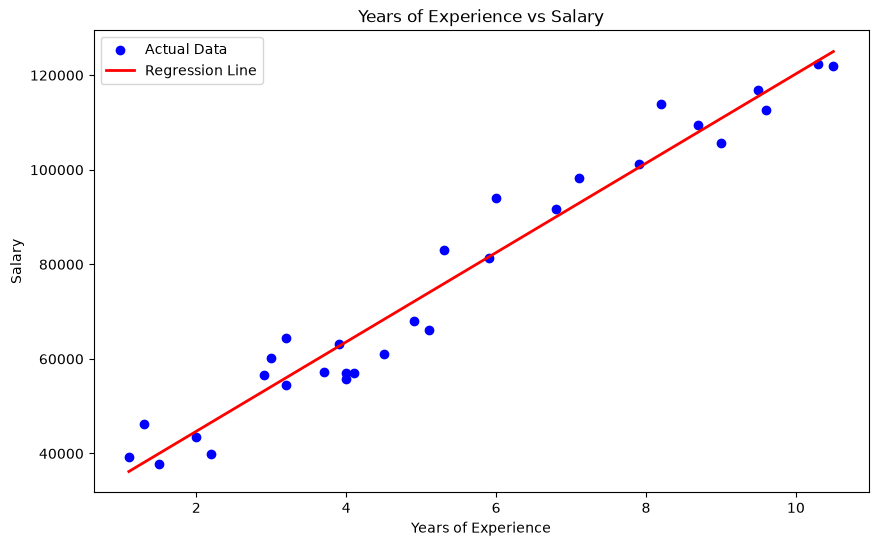

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(Salary_CSV['YearsExperience'], Salary_CSV['Salary'], color='blue', label='Actual Data')
plt.plot(Salary_CSV['YearsExperience'], Y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

### Classification Evaluation

In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

In [42]:
r2 = r2_score(Salary_CSV['Salary'], Y_pred)
mae = mean_absolute_error(Salary_CSV['Salary'], Y_pred)

### `R-squared Score`: Tells you what percentage of the variance in salary can be explained by years of experience.
### `Mean Absolute Error (MAE)`: Tells you, on average, how many dollars your model's salary predictions miss the real mark by.

In [43]:
print(f"R-squared Score: {r2:.4f}")
# Closer to 1.0 is perfect
print(f"Mean Absolute Error: ${mae:.2f}")

R-squared Score: 0.9570
Mean Absolute Error: $4644.20


### Custom Data Test

In [47]:
custom_experience = [[5.5]]
predicted_salary = model.predict(custom_experience)

In [48]:
print(f"Predicted Salary for 5.5 years of experience: ${predicted_salary[0]:,.2f}")

Predicted Salary for 5.5 years of experience: $77,766.99
